In [5]:
from cleaning import unzip_and_process
#unzip your file for cleaning
zip_path = './NS3astar/KYR3modified/Bicycle/Output/output.zip'
ready_for_cleaning = './NS3astar/KYR3modified/Bicycle/Output/output.csv'
unzip_and_process(zip_path, ready_for_cleaning)

Function called with: ./NS3astar/KYR3modified/Bicycle/Output/output.zip ./NS3astar/KYR3modified/Bicycle/Output/output.csv
Zip file opened successfully.
Extracted files: ['20250404-2057EJblTMB-KJ.txt']
Processing file: 20250404-2057EJblTMB-KJ.txt
Removing header...
Remaining lines after header removal:
0 0 XX XX XX Total 501993 648576

1 0 SDBfTevR EJ0.SDB21 AAAAAACTGCTGTTTGCAATTCCACTCGTGGTACCTTTCTATTCTCACTCTTCTATCTCTTGGTGCACTTACCATGACGACATGACTCAGCGTTGC SISWCTYHDDMTQRC 128396 149272

2 0 SDBfTevR EJ0.SDB21 AAAAAACTGCTGTTTGCAATTCCACTCGTGGTACCTTTCTATTCTCACTCTTCTACTCAGGAATGCTACCATTGGAACATGACTCTGGACAAATGC STQECYHWNMTLDKC 31985 41833

3 0 SDBfTevR EJ0.SDB21 AAAAAACTGCTGTTTGCAATTCCACTCGTGGTACCTTTCTATTCTCACTCTTCTGAATACAACTGCGTTCATCAGGACATGACTCAGTGGTGGTGC SEYNCVHQDMTQWWC 24681 30010

4 0 SDBfTevR EJ0.SDB21 AAAAAACTGCTGTTTGCAATTCCACTCGTGGTACCTTTCTATTCTCACTCTTCTCCGTCTGAATGCTACCATCGTGACATGACTTACTCTTTCTGC SPSECYHRDMTYSFC 18899 24202

5 0 SDBfTevR EJ0.SDB21 AAAAAACTGCTGTTTGCAATTCCACTCGTGGTACCTTTCTAT

In [6]:
from cleaning import cleaning

# Define your input and output file paths
input_file_1 = './NS3astar/KYR3modified/Bicycle/Input/input.csv'  #your input file
input_file_2 = './NS3astar/KYR3modified/Bicycle/Output/output.csv' #your output file
output_file = './NS3astar/KYR3modified/Bicycle/R3forDE.csv' #path for your file for DE analysis

# Call the function with the specified file paths
cleaning(input_file_1, input_file_2, output_file, pattern=r'^S...C.........C', library="EJ0.SDB21", baseline="EJ0.SDB17")
#Go to R, do TMM normalization (the R script is in the folder as well)

Total peptides: 311632
Library peptides: 68051
Library peptides matching pattern: 29109
Baseline peptides: 234487
Baseline peptides matching pattern: 7063
Peptides that are not strings (likely NaNs or floats):
[]
Matching peptides from library:
0     SISWCTYHDDMTQRC
1     SVQPCKWNPREAIVC
2     SPSECYHRDMTYSFC
3     STEWCPRASINMIEC
4     SEYNCVHQDMTQWWC
5     STSFCTIGNTHFKVC
7     SYQWCPSESIINIDC
8     STQECYHWNMTLDKC
9     SIVGCTWQPKEAVIC
10    SHQWCDPMIQEHKRC
Name: peptide, dtype: object
Total peptides: 217666
Library peptides: 82101
Library peptides matching pattern: 35412
Baseline peptides: 121763
Baseline peptides matching pattern: 5256
Peptides that are not strings (likely NaNs or floats):
[]
Matching peptides from library:
0     SISWCTYHDDMTQRC
1     STQECYHWNMTLDKC
2     SEYNCVHQDMTQWWC
3     SPSECYHRDMTYSFC
4     SYQWCPSESIINIDC
5     SPGWCYHSNMAKYVC
6     SQVHCYHGDMTMPIC
7     STEWCPRASINMIEC
8     SMVPCTHHDMTQWFC
10    SVQPCKWNPREAIVC
Name: peptide, dtype: object
Saving merge

In [7]:
from data_processing import process_afterDE

file_path = './NS3astar/KYR3modified/Bicycle/20250404/R3DE.txt' #file path after TMM normalization
output_path = './NS3astar/KYR3modified/Bicycle/20250404/reads_cpm_FC.csv' #gives you cpm reads and fold change

process_afterDE(file_path, output_path, library=r'^S...C.........C', inputtiter=9.75e8, outputtiter=5.43e6)

          sequence  reads1_input  reads2_input  reads1_output  reads2_output  \
1  AAACFFYSKNCGGSG      5.302939      0.000000       7.332496       2.914425   
3  AAACLPFYSRCEGSG      1.767646      0.000000       0.000000       0.000000   
5  AAACLPFYSRCGGSG     22.979404     16.697306      14.664991      32.058676   
7  AAACLPLYSRCGGSG      0.000000      2.782884       0.000000       0.000000   
8    AAACNFSTFCRGG      1.767646      0.000000       0.000000       0.000000   

    inputcpm  outputcpm  inputcpmplot  outputcpmplot        FC  group  \
1   4.315528   3.121822      5.315528       4.121822  0.775431      2   
3   1.438509   0.000000      2.438509       1.000000  0.410087      2   
5  32.288873  14.234812     33.288873      15.234812  0.457655      2   
7   2.264709   0.000000      3.264709       1.000000  0.306306      2   
8   1.438509   0.000000      2.438509       1.000000  0.410087      2   

     inputtiter  outputtiter  FractionalRecovery  
1   4207.639363    16.951496 

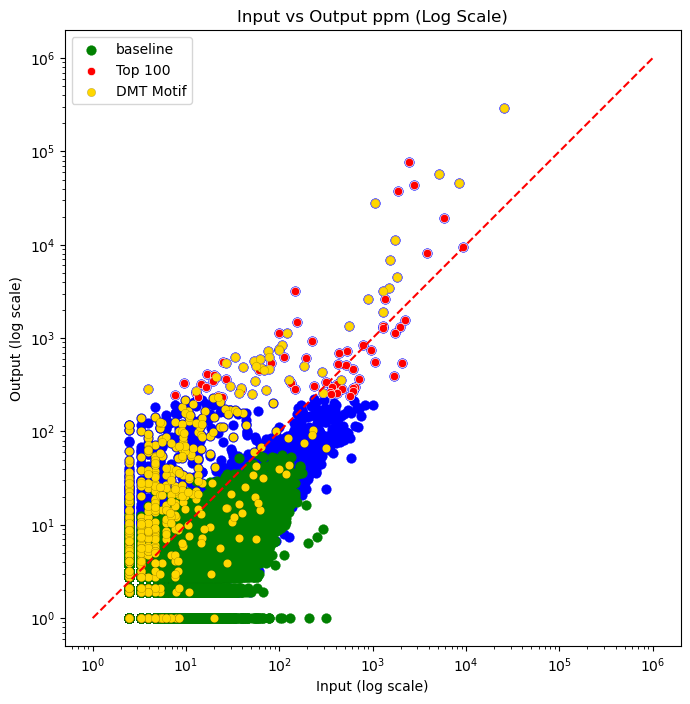

In [8]:
import pandas as pd
from DE_plot import plot_input_vs_output
df_path = './NS3astar//KYR3modified/Bicycle/20250404/reads_cpm_FC.csv'
df = pd.read_csv(df_path)
plot_input_vs_output(df, top_n=100, min_val=1, max_val=10**6, output_file='./NS3astar/KYR3modified/Bicycle/20250404/R3plot.png')

In [2]:
import pandas as pd
import numpy as np
from data_processing import process_afterDE
df= pd.read_csv('./NS3astar/s3c9c3roundunmodified/reads_cpm_FC.csv')
pattern1 = '^S...C.........C*$'  # Matches S3C9C-like patterns
pattern2 = '^A|SG$|GS$'
pattern3 = '(?=.*D)(?=.*Y)(?=.*K)' 
# Assign groups based on patterns
def assign_group(sequence):
    if pd.notnull(sequence):  # Ensure the sequence is not NaN
        if pd.Series(sequence).str.contains(pattern1, regex=True).any():
            return 1  # Group 1: Matches pattern1
        elif pd.Series(sequence).str.contains(pattern2, regex=True).any():
            return 2  # Group 2: Matches pattern2
        elif pd.Series(sequence).str.contains(pattern3, regex=True).any():
            return 3  # Group 3: Matches pattern3
        else:
            return 4  # Group 4: Does not match any pattern
    return None  # Handle NaN values

# Apply the function to assign groups
df['group'] = df['sequence'].apply(assign_group)

df.to_csv('./NS3astar/s3c9c3roundunmodified/reads_cpm_FC.csv')

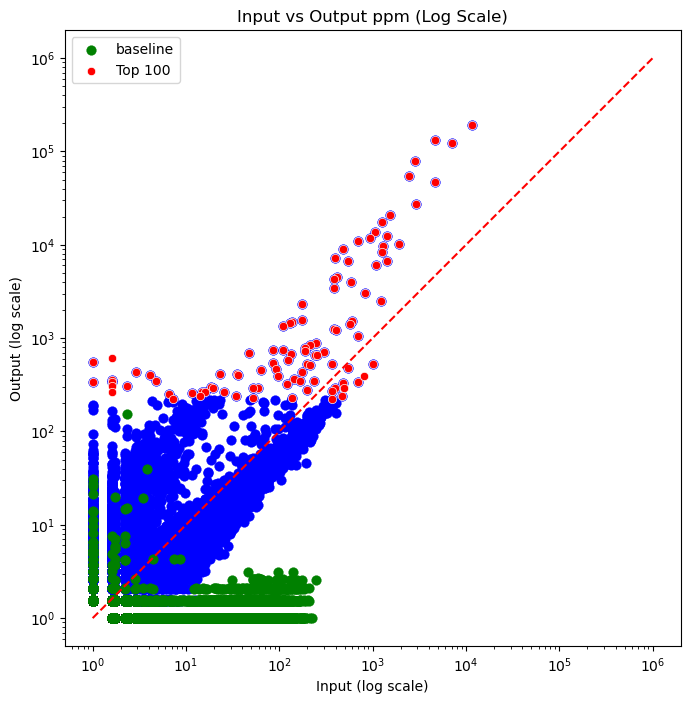

In [1]:
from DE_plot import plot_input_vs_output
import pandas as pd
df = pd.read_csv('./NS3astar/s3c9c3roundunmodified/reads_cpm_FC.csv')
df['inputcpmplot'] = df['inputcpm']+1
df['outputcpmplot'] = df['outputcpm']+1
plot_input_vs_output(df, top_n=100, motif = 'XXX', min_val=1, max_val=10**6, output_file='ns3star.png')

In [3]:
df

,Unnamed: 0.1,Unnamed: 0,sequence,inputcpm,outputcpm,FC,group,inputcpmplot,outputcpmplot
0,0,0,SISWCTYHDDMTQRC,11630.955560,192891.18850,16.582954,1,11631.955560,192892.18850
1,1,1,STEWCPRASINMIEC,4676.470773,134267.62990,28.705392,1,4677.470773,134268.62990
2,2,2,SVQPCKWNPREAIVC,7043.735367,124447.09580,17.665404,1,7044.735367,124448.09580
3,3,3,SYQWCPSESIINIDC,2839.612363,78260.02786,27.550759,1,2840.612363,78261.02786
4,4,4,STSFCTIGNTHFKVC,2444.538310,53953.12523,22.062269,1,2445.538310,53954.12523
...,...,...,...,...,...,...,...,...,...
555048,555048,555048,ACLPFYSHCGSGSGS,182.874897,0.00000,0.005438,2,183.874897,1.00000
555049,555049,555049,ACLPFHSRCGSGSGS,191.138057,0.00000,0.005205,2,192.138057,1.00000
555050,555050,555050,ACNGWLCTVGSGSGS,192.227325,0.00000,0.005175,2,193.227325,1.00000
555051,555051,555051,ACLPFYSSCGSGSGS,213.001779,0.00000,0.004673,2,214.001779,1.00000


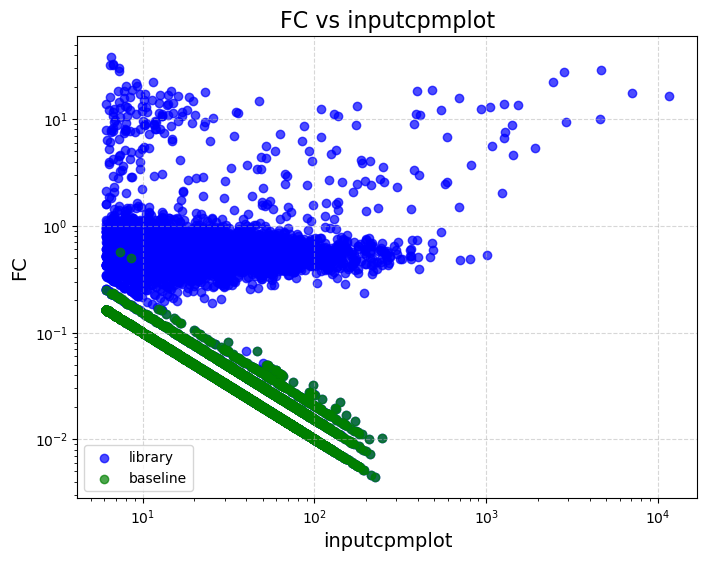

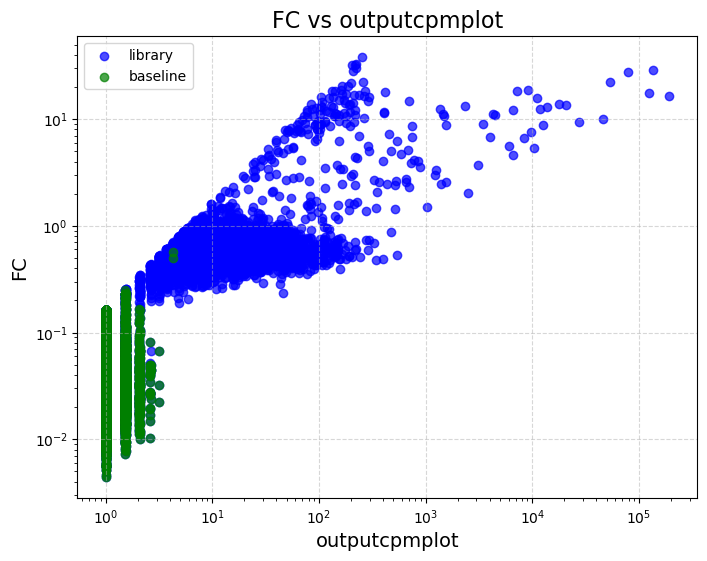

In [5]:
import matplotlib.pyplot as plt

# Assuming 'processed_data' is your DataFrame with relevant columns
def plot_fold_change_with_groups(data, x_column, y_column="FC", group_column=None, highlight_groups=None):
    """
    Plots Fold Change (y-axis) against a specified column (x-axis).

    Args:
        data (pd.DataFrame): Processed dataset.
        x_column (str): Column name to use for x-axis (e.g., 'inputcpm' or 'outputcpm').
        y_column (str): Column name to use for y-axis (default is 'FC').
    """
    plt.figure(figsize=(8, 6))
    
    # Plot all data points in default color
    plt.scatter(data[x_column], data[y_column], alpha=0.7, label="library", color="blue")
    
    if group_column and highlight_groups:
        # Highlight specified groups in red
        highlighted = data[data[group_column].isin(highlight_groups)]
        plt.scatter(highlighted[x_column], highlighted[y_column], alpha=0.7, label="baseline", color="green")
    
    # Add title and labels
    plt.title(f"{y_column} vs {x_column}", fontsize=16)
    plt.xlabel(x_column, fontsize=14)
    plt.ylabel(y_column, fontsize=14)
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Example usage
filtered_data = df[df["inputcpm"] > 5]

# Plot Fold Change against Input Value, highlighting groups 2, 3, 4
plot_fold_change_with_groups(
    data=filtered_data,
    x_column="inputcpmplot",
    y_column="FC",
    group_column=df.columns[6],  # Replace with the exact column name for group labels
    highlight_groups=[2, 3]
)

# Plot Fold Change against Output Value (log x-axis), highlighting groups 2, 3, 4
plot_fold_change_with_groups(
    data=filtered_data,
    x_column="outputcpmplot",
    y_column="FC",
    group_column=df.columns[6],  # Replace with the exact column name for group labels
    highlight_groups=[2, 3]
)

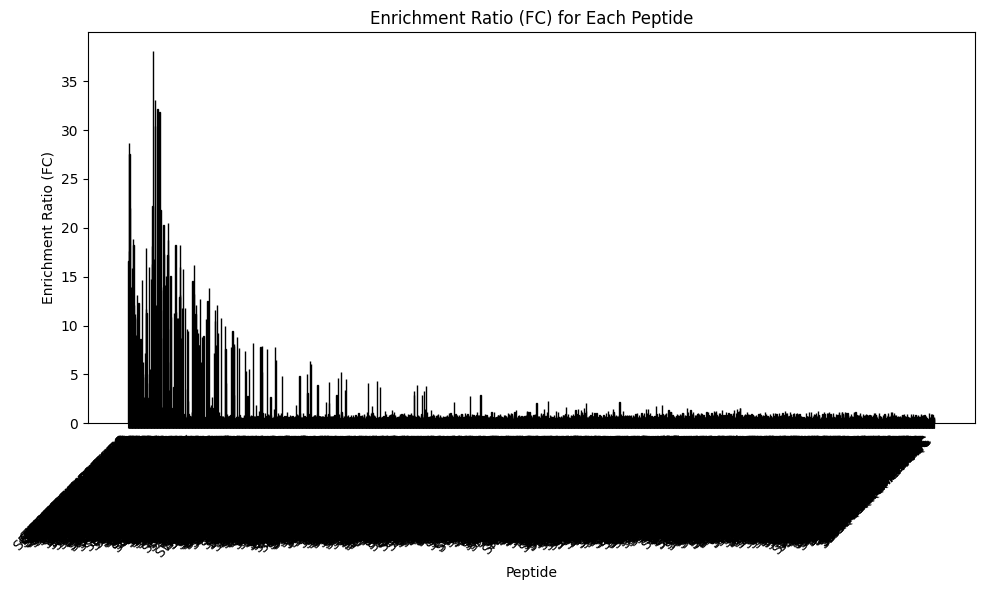

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def categorize_fc(fc):
    if fc < 1:
        return "FC < 1"
    elif 1 <= fc <= 2:
        return "1 ≤ FC ≤ 2"
    else:
        return "FC > 2"
df["Category"] = df["FC"].apply(categorize_fc)

color_map = {
    "FC < 1": "red",
    "1 ≤ FC ≤ 2": "blue",
    "FC > 2": "green",
}
df["Color"] = df["Category"].map(color_map)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(df["sequence"], df["FC"], color=df["Color"], edgecolor="k")
plt.title("Enrichment Ratio (FC) for Each Peptide")
plt.xlabel("Peptide")
plt.ylabel("Enrichment Ratio (FC)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

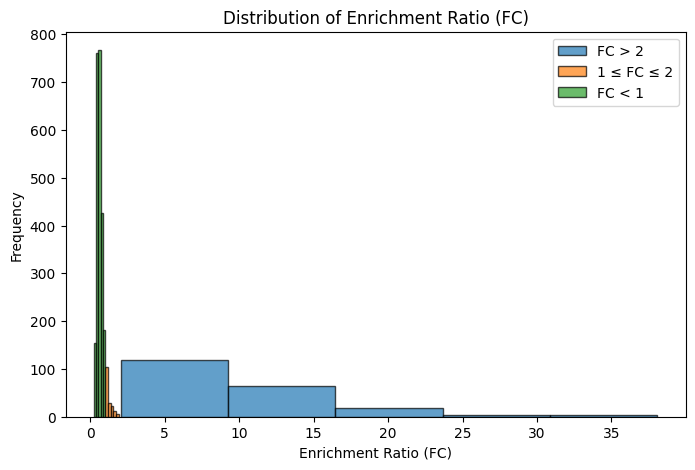

In [13]:
plt.figure(figsize=(8, 5))
categories = df["Category"].unique()
for category in categories:
    subset = df[df["Category"] == category]
    plt.hist(
        subset["FC"],
        bins=5,
        alpha=0.7,
        label=category,
        edgecolor="k",
    )


plt.title("Distribution of Enrichment Ratio (FC)")
plt.xlabel("Enrichment Ratio (FC)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [15]:
df

,sequence,inputcpm,outputcpm,FC,Category,Color
0,SISWCTYHDDMTQRC,11630.955560,192891.188500,16.582954,FC > 2,green
1,STEWCPRASINMIEC,4676.470773,134267.629900,28.705392,FC > 2,green
2,SVQPCKWNPREAIVC,7043.735367,124447.095800,17.665404,FC > 2,green
3,SYQWCPSESIINIDC,2839.612363,78260.027860,27.550759,FC > 2,green
4,STSFCTIGNTHFKVC,2444.538310,53953.125230,22.062269,FC > 2,green
...,...,...,...,...,...,...
3887,SMHQCSAEFSLKNNC,12.748375,5.359426,0.462558,FC < 1,red
3889,SSSACSQTQNYRYWC,18.335628,5.332102,0.327484,FC < 1,red
3890,STHWCQGQVTTDEGC,12.505221,5.326396,0.468441,FC < 1,red
3892,SDGQCENWMAHTYHC,9.592791,5.013310,0.567679,FC < 1,red


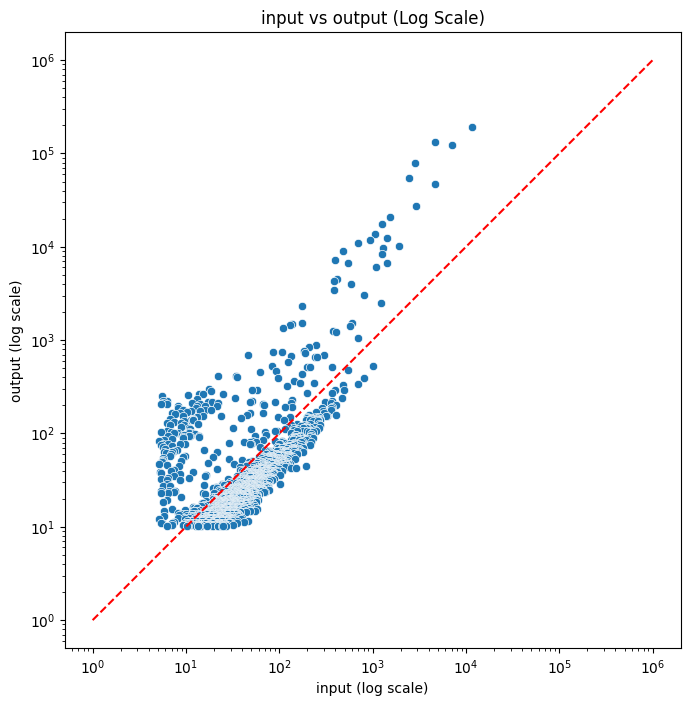

In [19]:
min_val = 1
max_val = 10**6

# Create diagonal line points
line_points = np.linspace(min_val, max_val, 100)
# Plot Output vs Input with log scale and diagonal line
plt.figure(figsize=(8, 8))
sns.scatterplot(x="inputcpm", y="outputcpm", data=df)
plt.plot(line_points, line_points, color='red', linestyle='--') # Diagonal line
plt.xscale('log')
plt.yscale('log')
plt.gca().set_aspect('equal', adjustable='box') # Set aspect ratio to be equal
plt.title('input vs output (Log Scale)')
plt.xlabel('input (log scale)')
plt.ylabel('output (log scale)')
plt.show()

In [2]:
new_df = df[['sequence', 'FC']]

In [3]:
def split_and_assign_group(df, train_ratio=0.7, valid_ratio=0.15, test_ratio=0.15):
    """
    Split the DataFrame into train, valid, and test groups and add a 'group' column.
    Args:
    - df: The input DataFrame
    - train_ratio: Proportion of the data for training (default 0.7)
    - valid_ratio: Proportion of the data for validation (default 0.15)
    - test_ratio: Proportion of the data for testing (default 0.15)
    
    Returns:
    - The updated DataFrame with a new 'group' column.
    """
    # Shuffle the DataFrame
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Compute split indices
    total_entries = len(df)
    train_end = int(train_ratio * total_entries)
    valid_end = train_end + int(valid_ratio * total_entries)
    
    # Assign group labels
    group_labels = np.array(['train'] * train_end + 
                            ['valid'] * (valid_end - train_end) + 
                            ['test'] * (total_entries - valid_end))
    
    # Add the group labels to the DataFrame
    df['group'] = group_labels
    
    return df
# Split and assign group
new_df = split_and_assign_group(new_df)

# Display the result
new_df

,sequence,FC,group
0,SPGWCYHSNMTKYVC,2.994237,train
1,SWMDCRVHNGQGTEC,0.944460,train
2,SYAYCKSAFPIKHQC,0.646819,train
3,SSRDCAHPEQVSSYC,0.475875,train
4,SSEQCSFTPNNHLTC,0.455486,train
...,...,...,...
4170,SNQICPPIPNKTIKC,0.376256,test
4171,SLIQCSNGSWMAGSC,0.455170,test
4172,SPYNCPSVMRTSTEC,1.138766,test
4173,SEWSCGHQYFPLNGC,1.050525,test


In [4]:
new_df.to_csv('ready_for_training3.csv', index=False)